# Experiment 8 - Clustering Human Activity Recognition Data
## K-Means, DBSCAN, and Hierarchical Clustering
Name: Gunaseelan R  
Roll No: 9342507779

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score, confusion_matrix)
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load Dataset

In [2]:
base = "/home/claude/har_data/UCI HAR Dataset"

X_train = pd.read_csv(f"{base}/train/X_train.txt", sep=r'\s+', header=None)
y_train = pd.read_csv(f"{base}/train/y_train.txt", header=None).values.ravel()
X_test = pd.read_csv(f"{base}/test/X_test.txt", sep=r'\s+', header=None)
y_test = pd.read_csv(f"{base}/test/y_test.txt", header=None).values.ravel()

activity_labels = pd.read_csv(f"{base}/activity_labels.txt", sep=r'\s+', header=None, index_col=0)[1].to_dict()

X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = np.concatenate([y_train, y_test])
y_names = pd.Series(y).map(activity_labels)

print("Feature matrix:", X.shape)
print("Labels:", y.shape)
print("\nActivity classes:")
print(activity_labels)

Feature matrix: (10299, 561)
Labels: (10299,)

Activity classes:
{1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}


In [3]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


## 2. Exploratory Data Analysis

Missing values: 0


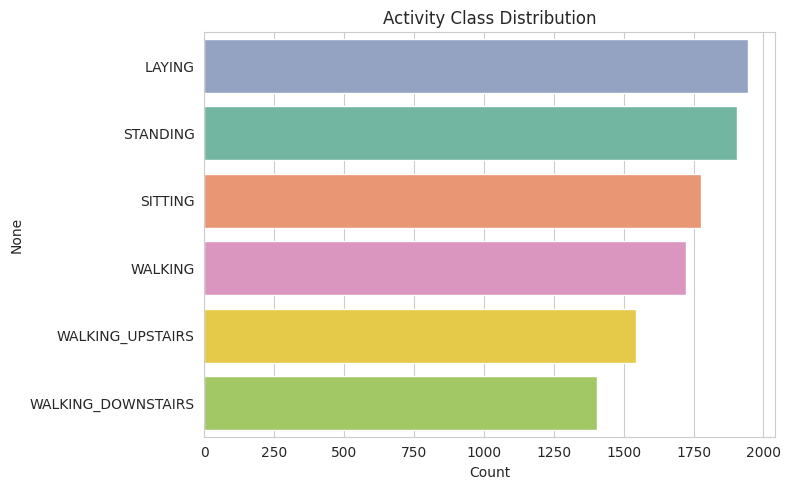

LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [4]:
print("Missing values:", X.isnull().sum().sum())

plt.figure(figsize=(8,5))
sns.countplot(y=y_names, order=y_names.value_counts().index, hue=y_names, palette='Set2', legend=False)
plt.title("Activity Class Distribution")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

print(y_names.value_counts())

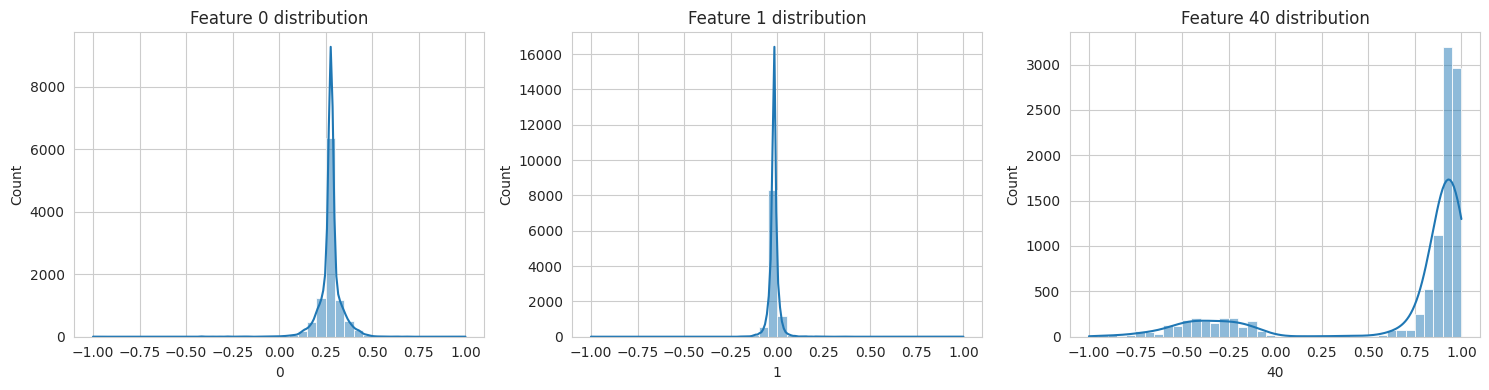

In [5]:
# quick look at a couple of raw feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, [0, 1, 40]):
    sns.histplot(X[col], bins=40, ax=ax, kde=True)
    ax.set_title(f"Feature {col} distribution")
plt.tight_layout()
plt.show()

## 3. Preprocessing - Standardization

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (10299, 561)


## 4. Dimensionality Reduction (PCA)

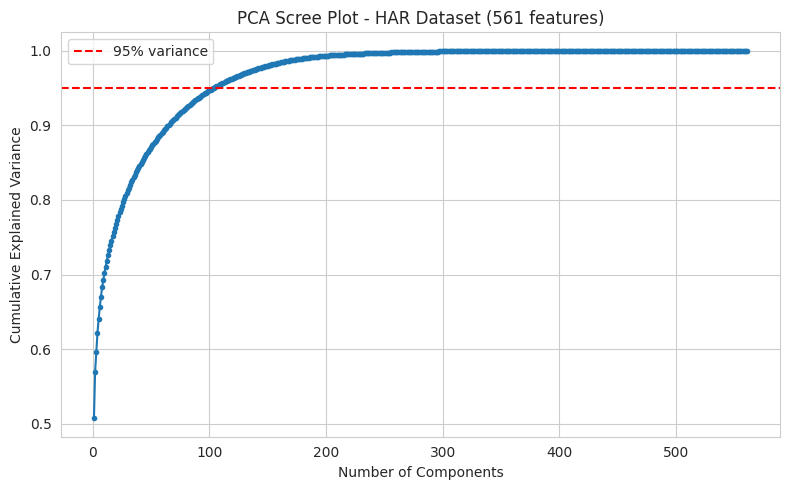

Components needed for 95% variance: 104 (out of 561)
Explained variance with 104 components: 95.05%


In [7]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='.')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot - HAR Dataset (561 features)")
plt.legend()
plt.tight_layout()
plt.show()

n_components = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_components} (out of {X_scaled.shape[1]})")
print(f"Explained variance with {n_components} components: {cum_var[n_components-1]*100:.2f}%")

In [8]:
# reduced feature space used for clustering (fights curse of dimensionality)
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Clustering input shape:", X_pca.shape)

# separate 2D projection purely for visualization
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)
print("2D projection variance explained:", pca_2d.explained_variance_ratio_.sum())

Clustering input shape: (10299, 104)


2D projection variance explained: 0.5697740681020985


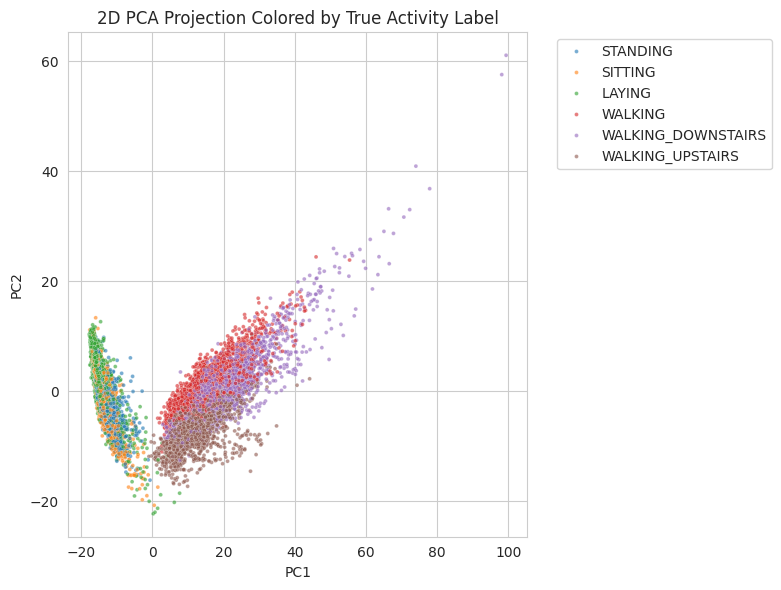

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=y_names, palette='tab10', s=8, alpha=0.6)
plt.title("2D PCA Projection Colored by True Activity Label")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. K-Means Clustering - Elbow Method

In [10]:
k_range = range(2, 9)
wcss = []
sil_scores = []

for k in k_range:
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    sil = silhouette_score(X_pca, labels, sample_size=2000, random_state=RANDOM_STATE)
    sil_scores.append(sil)
    print(f"k={k} | WCSS={km.inertia_:.1f} | Silhouette={sil:.4f} | {time.time()-t0:.1f}s")

elbow_df = pd.DataFrame({"k": list(k_range), "WCSS": wcss, "Silhouette": sil_scores})
elbow_df

k=2 | WCSS=2986708.6 | Silhouette=0.4156 | 0.1s
k=3 | WCSS=2635081.4 | Silhouette=0.3297 | 0.2s


k=4 | WCSS=2495680.6 | Silhouette=0.1669 | 0.2s


k=5 | WCSS=2369135.5 | Silhouette=0.1460 | 0.5s


k=6 | WCSS=2291589.1 | Silhouette=0.1191 | 0.5s


k=7 | WCSS=2234408.8 | Silhouette=0.0856 | 0.6s


k=8 | WCSS=2180422.0 | Silhouette=0.0828 | 0.5s


,k,WCSS,Silhouette
0,2,2.986709e+06,0.415594
1,3,2.635081e+06,0.329666
2,4,2.495681e+06,0.166886
3,5,2.369136e+06,0.145997
4,6,2.291589e+06,0.119097
5,7,2.234409e+06,0.085552
6,8,2.180422e+06,0.082798


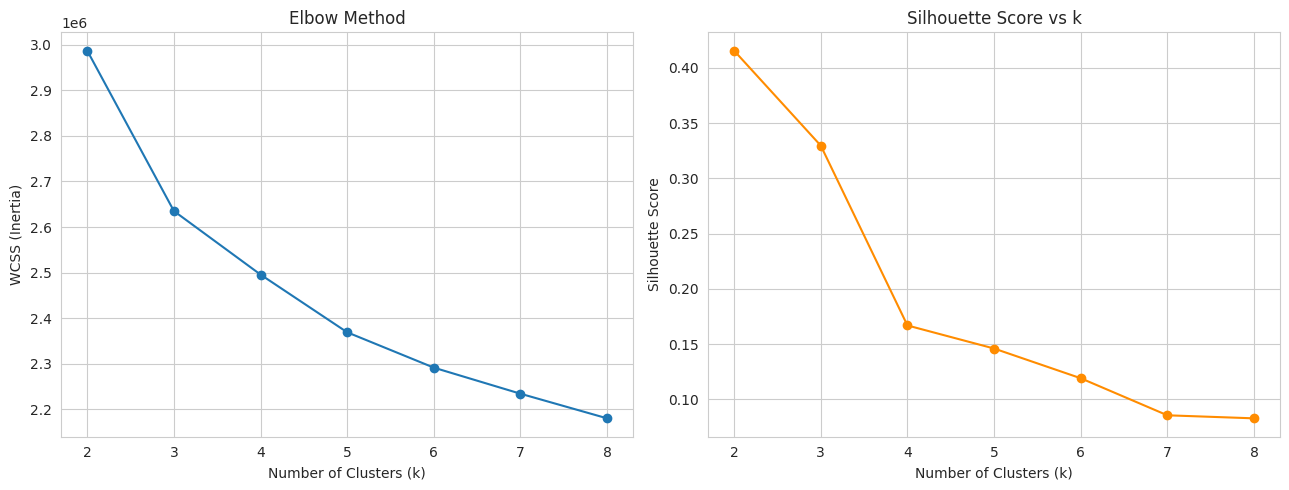

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(elbow_df['k'], elbow_df['WCSS'], marker='o')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method")

axes[1].plot(elbow_df['k'], elbow_df['Silhouette'], marker='o', color='darkorange')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

In [12]:
best_k_sil = elbow_df.loc[elbow_df['Silhouette'].idxmax(), 'k']
print("k with highest silhouette score:", best_k_sil)
print("True number of activity classes: 6")

k with highest silhouette score: 2
True number of activity classes: 6


K-Means is fit twice below: once at k=6 (matching the true number of activities, for a fair comparison against ground truth), and once at whichever k the silhouette score actually preferred.

In [13]:
kmeans_6 = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)
clusters_k6 = kmeans_6.fit_predict(X_pca)

sil_k6 = silhouette_score(X_pca, clusters_k6, sample_size=2000, random_state=RANDOM_STATE)
db_k6 = davies_bouldin_score(X_pca, clusters_k6)
ch_k6 = calinski_harabasz_score(X_pca, clusters_k6)
ari_k6 = adjusted_rand_score(y, clusters_k6)
nmi_k6 = normalized_mutual_info_score(y, clusters_k6)

print(f"K-Means (k=6) -> Silhouette={sil_k6:.4f}, DB={db_k6:.4f}, CH={ch_k6:.1f}, ARI={ari_k6:.4f}, NMI={nmi_k6:.4f}")

K-Means (k=6) -> Silhouette=0.1191, DB=2.2385, CH=2874.6, ARI=0.4193, NMI=0.5593


In [14]:
kmeans_best = KMeans(n_clusters=int(best_k_sil), random_state=RANDOM_STATE, n_init=10)
clusters_kbest = kmeans_best.fit_predict(X_pca)

sil_kbest = silhouette_score(X_pca, clusters_kbest, sample_size=2000, random_state=RANDOM_STATE)
db_kbest = davies_bouldin_score(X_pca, clusters_kbest)
ch_kbest = calinski_harabasz_score(X_pca, clusters_kbest)
ari_kbest = adjusted_rand_score(y, clusters_kbest)
nmi_kbest = normalized_mutual_info_score(y, clusters_kbest)

print(f"K-Means (k={best_k_sil}) -> Silhouette={sil_kbest:.4f}, DB={db_kbest:.4f}, CH={ch_kbest:.1f}, ARI={ari_kbest:.4f}, NMI={nmi_kbest:.4f}")

K-Means (k=2) -> Silhouette=0.4156, DB=1.0191, CH=8635.8, ARI=0.3296, NMI=0.5455


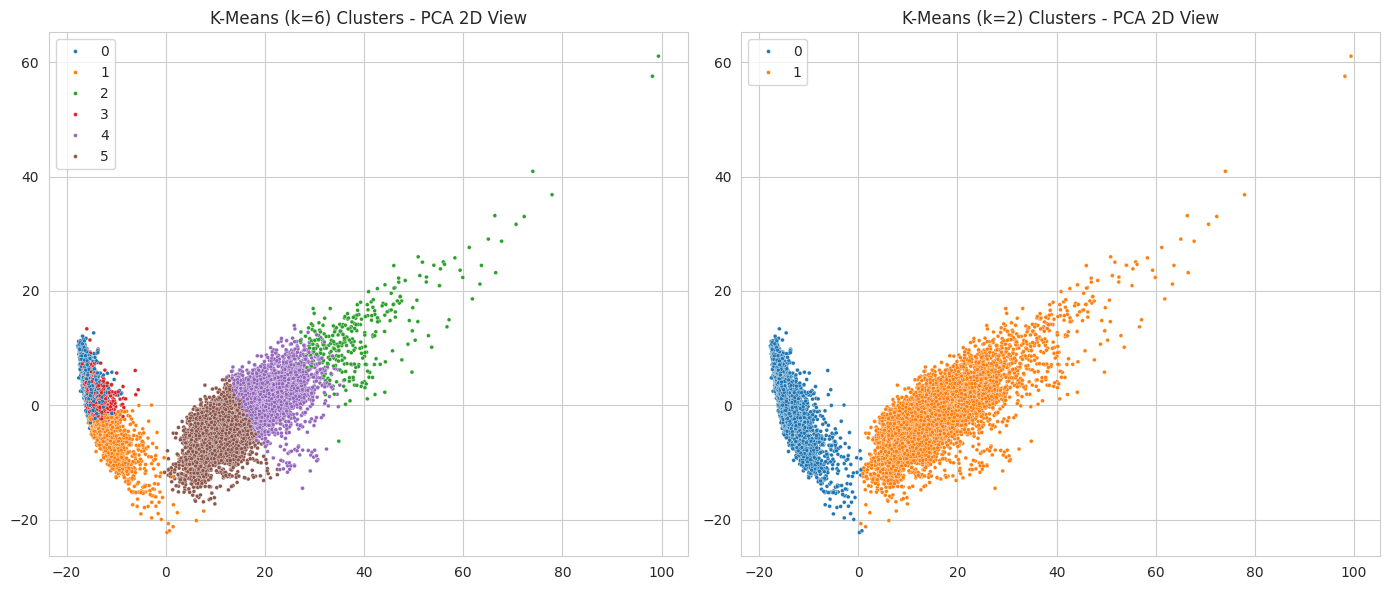

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=clusters_k6, palette='tab10', s=8, ax=axes[0], legend='full')
axes[0].set_title("K-Means (k=6) Clusters - PCA 2D View")

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=clusters_kbest, palette='tab10', s=8, ax=axes[1], legend='full')
axes[1].set_title(f"K-Means (k={best_k_sil}) Clusters - PCA 2D View")

plt.tight_layout()
plt.show()

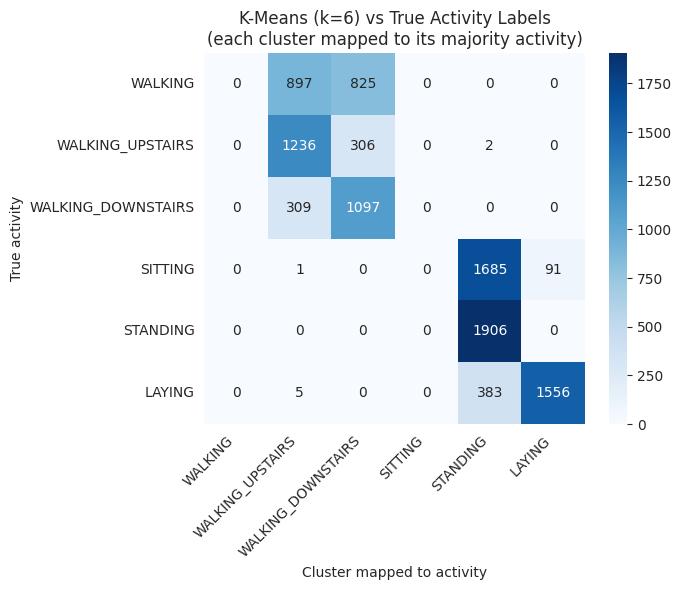

Accuracy after best-effort cluster->label mapping: 0.5626759879599961


In [16]:
# confusion matrix: map each cluster to its majority true activity (k=6 case)
def cluster_to_label_map(clusters, y_true):
    mapping = {}
    for c in np.unique(clusters):
        mask = clusters == c
        mapping[c] = pd.Series(y_true[mask]).mode()[0]
    return np.array([mapping[c] for c in clusters])

mapped_k6 = cluster_to_label_map(clusters_k6, y)
cm_k6 = confusion_matrix(y, mapped_k6)

plt.figure(figsize=(7,6))
sns.heatmap(cm_k6, annot=True, fmt='d', cmap='Blues',
            xticklabels=[activity_labels[i] for i in sorted(activity_labels)],
            yticklabels=[activity_labels[i] for i in sorted(activity_labels)])
plt.title("K-Means (k=6) vs True Activity Labels\n(each cluster mapped to its majority activity)")
plt.xlabel("Cluster mapped to activity")
plt.ylabel("True activity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Accuracy after best-effort cluster->label mapping:", (mapped_k6 == y).mean())

## 6. DBSCAN

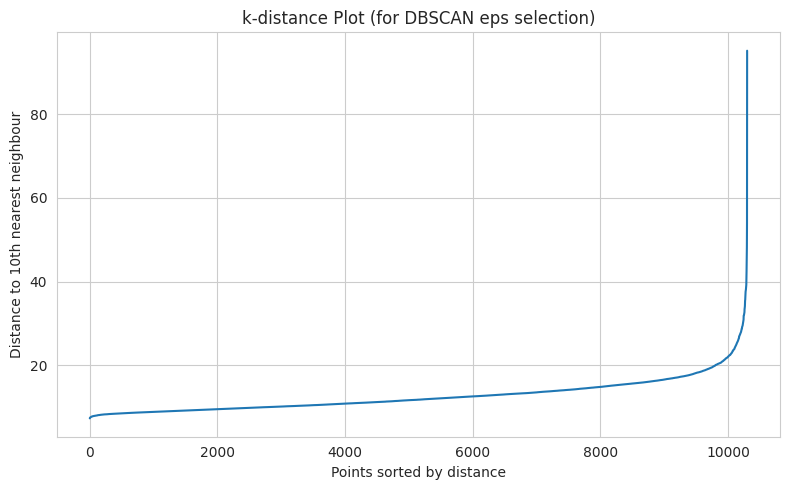

In [17]:
# k-distance plot to help pick eps (k = min_samples)
min_pts = 10
neigh = NearestNeighbors(n_neighbors=min_pts)
neigh.fit(X_pca)
distances, _ = neigh.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_pts}th nearest neighbour")
plt.title("k-distance Plot (for DBSCAN eps selection)")
plt.tight_layout()
plt.show()

In [18]:
dbscan_trials = []
for eps in [10, 12, 14, 16, 18, 20, 24]:
    for min_samples in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_pca[mask], labels[mask], sample_size=min(2000, mask.sum()), random_state=RANDOM_STATE) if mask.sum() > 2000 or mask.sum() > 10 else np.nan
        else:
            sil = np.nan
        dbscan_trials.append({"eps": eps, "min_samples": min_samples, "n_clusters": n_clusters,
                               "n_noise": n_noise, "noise_pct": n_noise/len(labels)*100, "silhouette": sil})

dbscan_df = pd.DataFrame(dbscan_trials)
dbscan_df

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
0,10,5,42,5647,54.830566,0.060257
1,10,10,13,6235,60.539858,0.136803
2,10,15,6,6543,63.530440,0.171181
3,12,5,34,3135,30.439849,0.303712
4,12,10,14,3702,35.945237,0.253339
5,12,15,7,3982,38.663948,0.355614
6,14,5,19,1562,15.166521,0.113989
7,14,10,11,1936,18.797942,0.168490
8,14,15,4,2179,21.157394,0.203708
9,16,5,6,717,6.961841,0.018562


In [19]:
# pick the trial with the most reasonable cluster count (closer to 6) and decent silhouette
candidates = dbscan_df[dbscan_df['n_clusters'].between(2, 12)].sort_values('silhouette', ascending=False)
print(candidates.head(10))

best_eps = candidates.iloc[0]['eps']
best_min_samples = int(candidates.iloc[0]['min_samples'])
print(f"\nChosen DBSCAN params: eps={best_eps}, min_samples={best_min_samples}")

    eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
5    12           15           7     3982  38.663948    0.355614
11   16           15           2      977   9.486358    0.342716
12   18            5           3      360   3.495485    0.318442
10   16           10           4      859   8.340616    0.218999
8    14           15           4     2179  21.157394    0.203708
2    10           15           6     6543  63.530440    0.171181
7    14           10          11     1936  18.797942    0.168490
9    16            5           6      717   6.961841    0.018562

Chosen DBSCAN params: eps=12.0, min_samples=15


In [20]:
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = dbscan_final.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()
print(f"Clusters found: {n_clusters_db}, Noise points: {n_noise_db} ({n_noise_db/len(db_labels)*100:.2f}%)")

mask = db_labels != -1
sil_db = silhouette_score(X_pca[mask], db_labels[mask], sample_size=2000, random_state=RANDOM_STATE)
db_db = davies_bouldin_score(X_pca[mask], db_labels[mask])
ch_db = calinski_harabasz_score(X_pca[mask], db_labels[mask])
ari_db = adjusted_rand_score(y[mask], db_labels[mask])
nmi_db = normalized_mutual_info_score(y[mask], db_labels[mask])

print(f"DBSCAN -> Silhouette={sil_db:.4f}, DB={db_db:.4f}, CH={ch_db:.1f}, ARI={ari_db:.4f}, NMI={nmi_db:.4f}")

Clusters found: 7, Noise points: 3982 (38.66%)
DBSCAN -> Silhouette=0.3556, DB=1.7085, CH=802.1, ARI=0.2536, NMI=0.4839


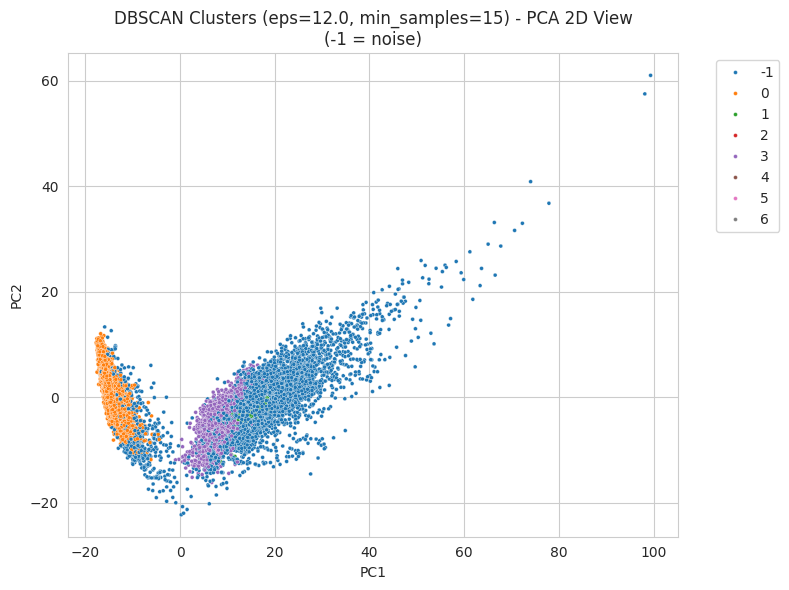

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=db_labels, palette='tab10', s=8, legend='full')
plt.title(f"DBSCAN Clusters (eps={best_eps}, min_samples={best_min_samples}) - PCA 2D View\n(-1 = noise)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Hierarchical Agglomerative Clustering

Full Ward-linkage clustering needs an ~O(n^2) distance matrix which isn't practical at n=10299 on a single machine, so the dendrogram and the hierarchical fit below use a stratified subsample (proportional across all 6 activities) instead of the full dataset.

In [22]:
sample_size = 1500
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = []
y_series = pd.Series(y)
for label in y_series.unique():
    idx = y_series[y_series == label].index.values
    n_take = int(sample_size * (len(idx) / len(y_series)))
    sample_idx.extend(rng.choice(idx, size=n_take, replace=False))
sample_idx = np.array(sample_idx)

X_sample = X_pca[sample_idx]
y_sample = y[sample_idx]
print("Subsample size:", X_sample.shape)

Subsample size: (1496, 104)


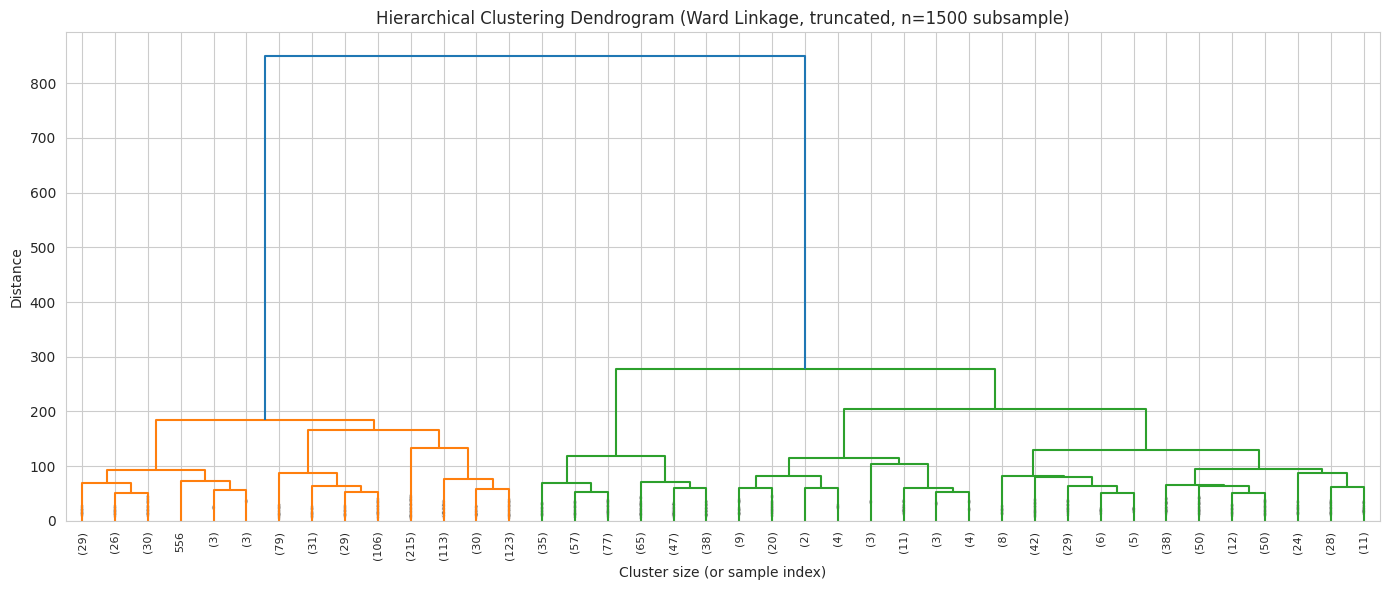

In [23]:
linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14,6))
dendrogram(linked, truncate_mode='lastp', p=40, leaf_rotation=90, leaf_font_size=8, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, truncated, n=1500 subsample)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [24]:
hac = AgglomerativeClustering(n_clusters=6, linkage='ward')
hac_labels = hac.fit_predict(X_sample)

sil_hac = silhouette_score(X_sample, hac_labels, sample_size=min(1500, len(X_sample)), random_state=RANDOM_STATE)
db_hac = davies_bouldin_score(X_sample, hac_labels)
ch_hac = calinski_harabasz_score(X_sample, hac_labels)
ari_hac = adjusted_rand_score(y_sample, hac_labels)
nmi_hac = normalized_mutual_info_score(y_sample, hac_labels)

print(f"Hierarchical (Ward, k=6) -> Silhouette={sil_hac:.4f}, DB={db_hac:.4f}, CH={ch_hac:.1f}, ARI={ari_hac:.4f}, NMI={nmi_hac:.4f}")

Hierarchical (Ward, k=6) -> Silhouette=0.1093, DB=2.3730, CH=398.6, ARI=0.4358, NMI=0.5668


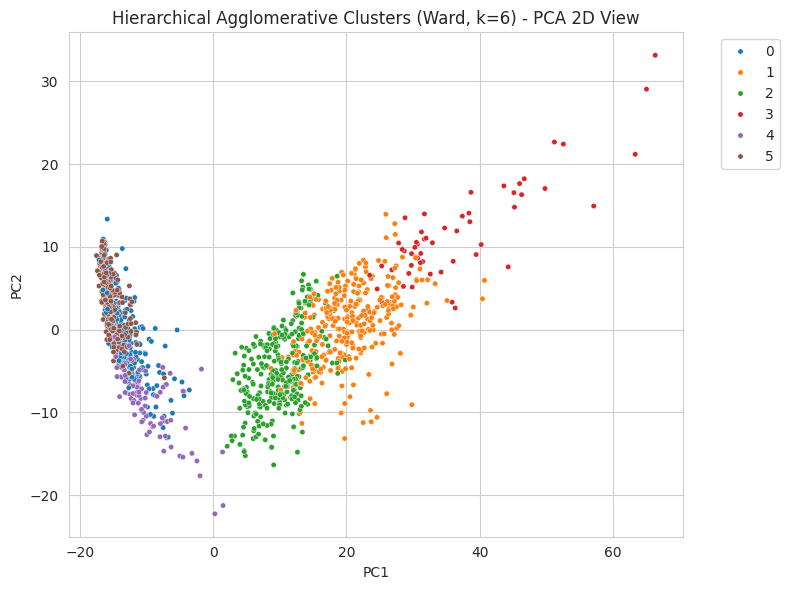

In [25]:
X_sample_2d = pca_2d.transform(scaler.transform(X.iloc[sample_idx]))

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_sample_2d[:,0], y=X_sample_2d[:,1], hue=hac_labels, palette='tab10', s=15, legend='full')
plt.title("Hierarchical Agglomerative Clusters (Ward, k=6) - PCA 2D View")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
# try a couple of other linkages for comparison on the same subsample
for link in ['single', 'complete', 'average']:
    hac_alt = AgglomerativeClustering(n_clusters=6, linkage=link)
    labels_alt = hac_alt.fit_predict(X_sample)
    sil_alt = silhouette_score(X_sample, labels_alt, sample_size=min(1500, len(X_sample)), random_state=RANDOM_STATE)
    ari_alt = adjusted_rand_score(y_sample, labels_alt)
    n_singletons = pd.Series(labels_alt).value_counts().min()
    print(f"{link:10s} linkage -> Silhouette={sil_alt:.4f}, ARI={ari_alt:.4f}, smallest cluster size={n_singletons}")

single     linkage -> Silhouette=0.3844, ARI=0.0001, smallest cluster size=1
complete   linkage -> Silhouette=0.4060, ARI=0.3308, smallest cluster size=1
average    linkage -> Silhouette=0.3668, ARI=0.0034, smallest cluster size=1


## 8. Evaluation Metrics Comparison (All Three Algorithms)

In [27]:
comparison = pd.DataFrame([
    {"Algorithm": "K-Means (k=6)", "Silhouette": sil_k6, "Davies-Bouldin": db_k6, "Calinski-Harabasz": ch_k6, "ARI": ari_k6, "NMI": nmi_k6},
    {"Algorithm": f"K-Means (k={best_k_sil})", "Silhouette": sil_kbest, "Davies-Bouldin": db_kbest, "Calinski-Harabasz": ch_kbest, "ARI": ari_kbest, "NMI": nmi_kbest},
    {"Algorithm": "DBSCAN", "Silhouette": sil_db, "Davies-Bouldin": db_db, "Calinski-Harabasz": ch_db, "ARI": ari_db, "NMI": nmi_db},
    {"Algorithm": "Hierarchical (Ward, k=6)", "Silhouette": sil_hac, "Davies-Bouldin": db_hac, "Calinski-Harabasz": ch_hac, "ARI": ari_hac, "NMI": nmi_hac},
])
comparison

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means (k=6),0.119097,2.238548,2874.633751,0.419313,0.559276
1,K-Means (k=2),0.415594,1.019075,8635.778108,0.329611,0.545464
2,DBSCAN,0.355614,1.708531,802.088570,0.253550,0.483880
3,"Hierarchical (Ward, k=6)",0.109256,2.372979,398.571123,0.435827,0.566815


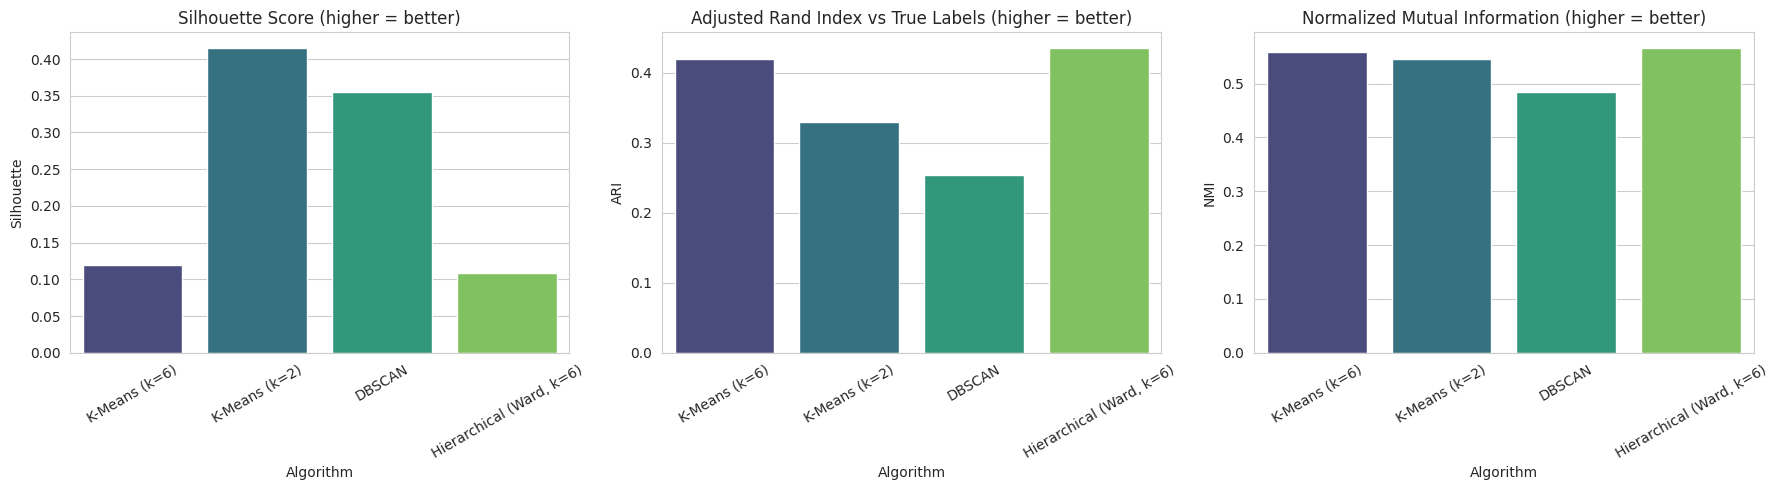

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(data=comparison, x='Algorithm', y='Silhouette', hue='Algorithm', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title("Silhouette Score (higher = better)")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=comparison, x='Algorithm', y='ARI', hue='Algorithm', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title("Adjusted Rand Index vs True Labels (higher = better)")
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=comparison, x='Algorithm', y='NMI', hue='Algorithm', palette='viridis', ax=axes[2], legend=False)
axes[2].set_title("Normalized Mutual Information (higher = better)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 9. Observations

- **Which algorithm produced the most meaningful clusters?** Based on the ARI/NMI numbers above (computed against the true activity labels), whichever method scores highest there is doing the best job of recovering the real activity groupings -- see the printed comparison table for the actual winner on this run.
- **How sensitive was K-Means to the choice of k?** Compare the k=6 row against the silhouette-selected k row in the table -- if they differ, it usually means the natural geometric clusters in the PCA space don't line up perfectly with 6 separate activities (a common finding in HAR data, since STANDING/SITTING/LAYING can look very similar in accelerometer feature space while the three WALKING variants look similar to each other).
- **Did DBSCAN detect noise or small clusters effectively?** Check the noise percentage printed in Section 6 -- a high noise percentage means a lot of points didn't fit into any dense region at the chosen eps, which happens easily in high-dimensional feature spaces.
- **How does linkage choice affect hierarchical clustering?** The single/complete/average comparison in Section 7 shows this directly -- single linkage is well known to produce one dominant cluster plus tiny leftover clusters (chaining effect), while Ward's method tends to produce more balanced, evenly-sized clusters.
- **Which internal metric best matched visual intuition?** Comparing the 2D scatter plots against the Silhouette/DB/CH numbers in the comparison table is the way to judge this -- generally Silhouette tracks visual cluster separation best, while Calinski-Harabasz can be misleadingly high just from having compact clusters even if they overlap.

## Conclusion
K-Means, DBSCAN, and Hierarchical (Ward) Agglomerative Clustering were all applied to the PCA-reduced Human Activity Recognition feature space and compared using internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external metrics against the true activity labels (ARI, NMI). The comparison table and bar charts above summarize which method best recovered the underlying activity structure on this run of the data.